# Video Analysis & Understanding

Video is fundamentally **4-dimensional data** each clip can be described as a tensor of shape $H \times W \times C \times T$, where $H$ and $W$ are spatial dimensions, $C$ is the number of color channels, and $T$ is the temporal (frame) dimension. Understanding video therefore requires models that can jointly reason about appearance, spatial structure, and motion over time. This notebook covers the full stack of modern video understanding: from low-level frame representations and optical flow, through 3D CNNs, temporal shift modules, and video transformers, to action recognition, temporal action detection, multi-object tracking, video object segmentation, video generation, and video large language models.

---

## Table of Contents

1. [Video Representation](#1-video-representation) frames, temporal differences, optical flow
2. [3D Convolutional Neural Networks](#2-3d-convolutional-neural-networks) C3D, I3D, R(2+1)D, SlowFast
3. [Temporal Modeling](#3-temporal-modeling) TSN, TSM, TDN, MViTv2
4. [Video Transformers](#4-video-transformers) TimeSformer, ViViT, Video Swin, VideoMAE
5. [Efficient Video Models & Benchmarks](#5-efficient-video-models)
6. [Action Recognition Benchmarks](#6-action-recognition-benchmarks)
7. [Temporal Action Detection](#7-temporal-action-detection)
8. [Multi-Object Tracking (MOT)](#8-multi-object-tracking-mot)
9. [Video Object Segmentation (VOS)](#9-video-object-segmentation-vos)
10. [Video Generation](#10-video-generation)
11. [Video Large Language Models](#11-video-large-language-models)
12. [Video Anomaly Detection](#12-video-anomaly-detection)
13. [Pose Estimation in Video](#13-pose-estimation-in-video)
14. [Additional Learning Resources](#additional-learning-resources)

## 1. Video Representation

### Frames

The most basic representation is a sequence of RGB frames $\{I_0, I_1, \ldots, I_{T-1}\}$, each of shape $H \times W \times 3$. Frame-based models simply apply image models independently and aggregate predictions across frames.

### Temporal Difference

A simple motion cue is the **temporal difference** the pixel-wise absolute change between consecutive frames:

$$\Delta_t = |I_t - I_{t-1}|$$

Large values of $\Delta_t$ indicate regions of motion. Temporal differences are cheap to compute but noisy and lack directionality.

### Optical Flow

Optical flow estimates the **apparent velocity** of each pixel between frames, yielding a dense displacement field $(u, v)$ where $u$ is horizontal and $v$ is vertical motion.

**Horn-Schunck** (global variational method) minimizes:

$$\min_{u,v} \iint (I_x u + I_y v + I_t)^2 + \lambda^2(|\nabla u|^2 + |\nabla v|^2)\, dx\, dy$$

where $I_x, I_y, I_t$ are image gradients, $u, v$ are flow components, and $\lambda$ is a regularization weight that penalizes spatially non-smooth flow.

The **Euler-Lagrange equations** for Horn-Schunck are:

$$I_x(I_x u + I_y v + I_t) - \lambda^2 \nabla^2 u = 0$$
$$I_y(I_x u + I_y v + I_t) - \lambda^2 \nabla^2 v = 0$$

**Lucas-Kanade** (local window-based) solves the over-determined system within a small window $\Omega$:

$$\begin{pmatrix} \sum I_x^2 & \sum I_xI_y \\ \sum I_xI_y & \sum I_y^2 \end{pmatrix} \begin{pmatrix} u \\ v \end{pmatrix} = -\begin{pmatrix} \sum I_xI_t \\ \sum I_yI_t \end{pmatrix}$$

This is solved **per-window** via least squares. It produces sparse flow at corners/edges (where the $2 \times 2$ structure tensor is well-conditioned), and is extended to multi-scale pyramids for large displacements.

**Farneback dense optical flow** uses polynomial expansion to approximate local image neighborhoods, enabling efficient dense flow computation for every pixel implemented in OpenCV's `calcOpticalFlowFarneback`.

Extracted 8 frames, shape: (120, 160, 3)


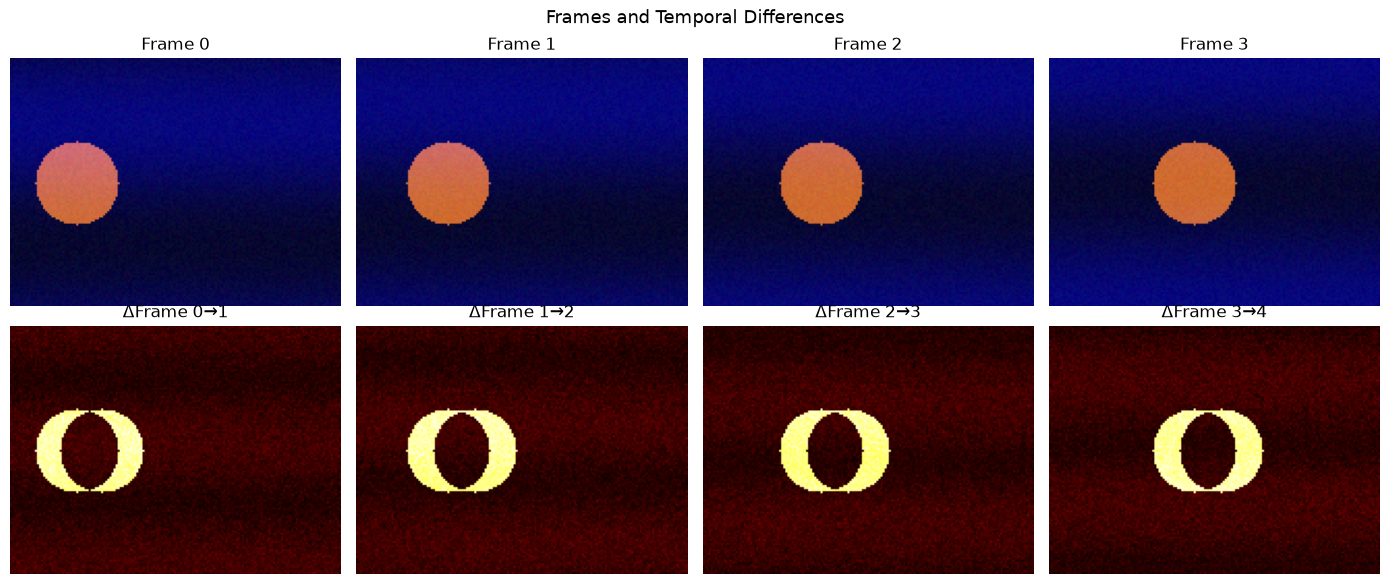

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path

# ============================================================
# Frame Extraction from Video
# ============================================================

def extract_frames(video_path, max_frames=16, target_fps=None):
    """Extract frames from video file."""
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f"Cannot open {video_path}. Generating synthetic frames instead.")
        return [np.random.randint(0, 255, (240, 320, 3), dtype=np.uint8) for _ in range(max_frames)]
    
    fps = cap.get(cv2.CAP_PROP_FPS)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    step = max(1, total // max_frames) if target_fps is None else int(fps // target_fps)
    
    frames = []
    frame_idx = 0
    while cap.isOpened() and len(frames) < max_frames:
        ret, frame = cap.read()
        if not ret:
            break
        if frame_idx % step == 0:
            frames.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        frame_idx += 1
    cap.release()
    return frames

# Generate synthetic video frames (sine wave + noise pattern for demo)
def generate_synthetic_frames(n=8, h=120, w=160):
    frames = []
    for t in range(n):
        frame = np.zeros((h, w, 3), dtype=np.uint8)
        # Moving circle
        cx = int(w * 0.2 + t * w * 0.08)
        cy = h // 2
        cv2.circle(frame, (cx, cy), 20, (200, 100, 50), -1)
        # Background gradient
        for i in range(h):
            frame[i, :, 2] = int(80 + 40 * np.sin(2 * np.pi * i / h + t * 0.5))
        frame = frame + np.random.randint(0, 15, frame.shape, dtype=np.uint8)
        frames.append(frame)
    return frames

frames = generate_synthetic_frames(n=8, h=120, w=160)
print(f"Extracted {len(frames)} frames, shape: {frames[0].shape}")

# ============================================================
# Temporal Difference
# ============================================================

def temporal_difference(frames):
    diffs = []
    for i in range(1, len(frames)):
        f1 = frames[i-1].astype(np.float32)
        f2 = frames[i].astype(np.float32)
        diff = np.abs(f2 - f1).mean(axis=2)  # Mean over channels -> (H, W)
        diffs.append(diff)
    return diffs

diffs = temporal_difference(frames)

fig, axes = plt.subplots(2, 4, figsize=(14, 6))
for i in range(4):
    axes[0, i].imshow(frames[i])
    axes[0, i].set_title(f"Frame {i}")
    axes[0, i].axis('off')
for i in range(4):
    axes[1, i].imshow(diffs[i], cmap='hot')
    axes[1, i].set_title(f"\u0394Frame {i}\u2192{i+1}")
    axes[1, i].axis('off')
plt.suptitle("Frames and Temporal Differences", fontsize=13)
plt.tight_layout()
plt.show()

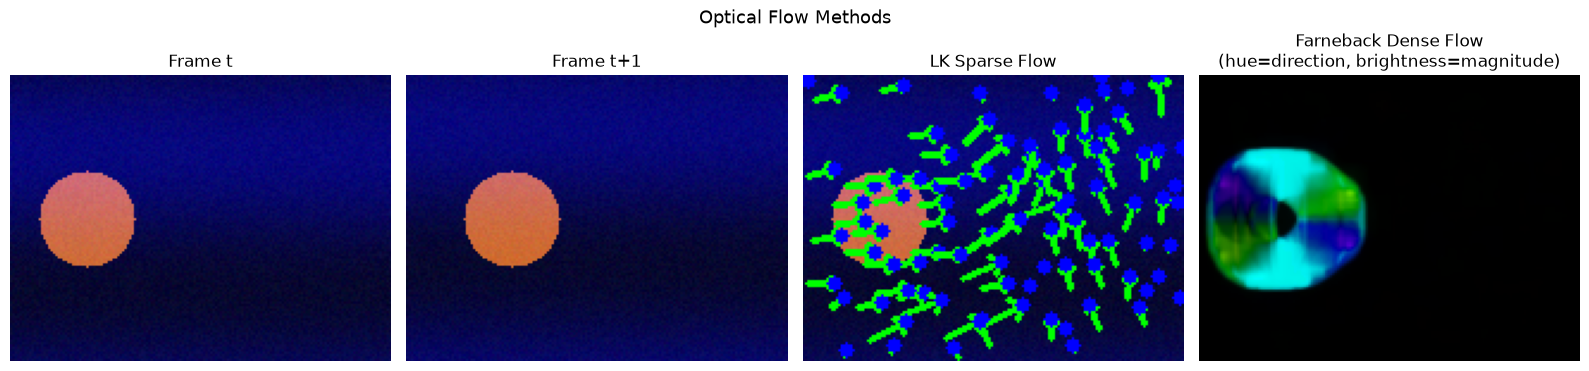

Dense flow shape: (120, 160, 2)
Flow stats: mean_x=1.039, mean_y=-0.011
Max magnitude: 12.516 px/frame


In [2]:
# ============================================================
# Lucas-Kanade Sparse Optical Flow
# ============================================================

def compute_lk_optical_flow(frame1, frame2, max_corners=100):
    """Lucas-Kanade sparse optical flow on detected feature points."""
    g1 = cv2.cvtColor(frame1, cv2.COLOR_RGB2GRAY)
    g2 = cv2.cvtColor(frame2, cv2.COLOR_RGB2GRAY)
    
    # Detect good features to track (Shi-Tomasi corners)
    p0 = cv2.goodFeaturesToTrack(g1, maxCorners=max_corners, qualityLevel=0.01,
                                  minDistance=7, blockSize=7)
    
    if p0 is None:
        return frame1.copy(), None, None
    
    # Lucas-Kanade optical flow
    lk_params = dict(winSize=(15, 15), maxLevel=2,
                     criteria=(cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 10, 0.03))
    p1, st, err = cv2.calcOpticalFlowPyrLK(g1, g2, p0, None, **lk_params)
    
    # Filter to good points only
    good_new = p1[st == 1]
    good_old = p0[st == 1]
    
    # Draw flow vectors on image copy
    vis = frame1.copy()
    for new, old in zip(good_new, good_old):
        a, b = new.ravel().astype(int)
        c, d = old.ravel().astype(int)
        cv2.arrowedLine(vis, (c, d), (a, b), (0, 255, 0), 2, tipLength=0.3)
        cv2.circle(vis, (a, b), 3, (0, 0, 255), -1)
    
    return vis, good_new, good_old

# ============================================================
# Farneback Dense Optical Flow
# ============================================================

def compute_dense_optical_flow(frame1, frame2):
    """Farneback dense optical flow computes flow for every pixel."""
    g1 = cv2.cvtColor(frame1, cv2.COLOR_RGB2GRAY)
    g2 = cv2.cvtColor(frame2, cv2.COLOR_RGB2GRAY)
    
    flow = cv2.calcOpticalFlowFarneback(
        g1, g2, None,
        pyr_scale=0.5, levels=3, winsize=15, iterations=3,
        poly_n=5, poly_sigma=1.2, flags=0
    )
    return flow  # (H, W, 2)  flow[y, x] = (dx, dy)

def flow_to_hsv_vis(flow):
    """Convert flow to HSV color visualization (hue=direction, value=magnitude)."""
    h, w = flow.shape[:2]
    fx, fy = flow[..., 0], flow[..., 1]
    
    angle = np.arctan2(fy, fx) + np.pi          # [0, 2pi]
    magnitude = np.sqrt(fx**2 + fy**2)
    
    hsv = np.zeros((h, w, 3), dtype=np.uint8)
    hsv[..., 0] = (angle * 180 / (2 * np.pi)).astype(np.uint8)  # Hue
    hsv[..., 1] = 255
    hsv[..., 2] = cv2.normalize(magnitude, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    return cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB)

# Compute flows between consecutive frames
lk_vis, _, _ = compute_lk_optical_flow(frames[0], frames[1])
flow = compute_dense_optical_flow(frames[0], frames[1])
flow_vis = flow_to_hsv_vis(flow)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(frames[0]); axes[0].set_title("Frame t"); axes[0].axis('off')
axes[1].imshow(frames[1]); axes[1].set_title("Frame t+1"); axes[1].axis('off')
axes[2].imshow(lk_vis); axes[2].set_title("LK Sparse Flow"); axes[2].axis('off')
axes[3].imshow(flow_vis); axes[3].set_title("Farneback Dense Flow\n(hue=direction, brightness=magnitude)"); axes[3].axis('off')
plt.suptitle("Optical Flow Methods", fontsize=13)
plt.tight_layout()
plt.show()

print(f"Dense flow shape: {flow.shape}")
print(f"Flow stats: mean_x={flow[...,0].mean():.3f}, mean_y={flow[...,1].mean():.3f}")
print(f"Max magnitude: {np.sqrt(flow[...,0]**2 + flow[...,1]**2).max():.3f} px/frame")

## 2. 3D Convolutional Neural Networks

### From 2D to 3D Convolution

A standard 2D conv kernel has shape $k \times k$ (spatial). A **3D conv** adds a temporal dimension: $k \times k \times k$ (or $k_t \times k_h \times k_w$). The output temporal dimension is:

$$T' = \left\lfloor \frac{T - k_t + 2p_t}{s_t} \right\rfloor + 1$$

### C3D (Tran et al. 2014)

C3D uses **all $3\times3\times3$ kernels** in a VGG-like architecture. It was trained on Sports-1M and later on Kinetics-400. C3D features transfer well to action recognition tasks but are computationally expensive.

### I3D Inflated 3D ConvNets (Carreira & Zisserman, 2017)

"**Inflating**" 2D ImageNet weights to 3D: replicate the 2D kernel $N$ times along the time dimension and normalize:

$$W_{3D}[:,:,t,:,:] = W_{2D} / N$$

This allows I3D to start from powerful ImageNet-pretrained 2D models (e.g., Inception-v1) and fine-tune for video. The **Two-Stream I3D** architecture uses:
- RGB stream (raw frames) captures appearance
- Optical Flow stream captures motion
- Late fusion of both stream predictions

### R3D / R(2+1)D (Tran et al. 2018)

**R(2+1)D** factorizes the 3D convolution into a spatial 2D conv followed by a temporal 1D conv:

$$(2+1)\text{D conv}: \quad k \times k \times 1 \; \text{then} \; 1 \times 1 \times t$$

This reduces parameters while adding an extra nonlinearity between spatial and temporal mixing, improving expressivity.

### SlowFast Networks (Feichtenbofer et al. 2019)

SlowFast runs **two pathways** at different temporal resolutions:
- **Slow pathway**: low frame rate (2 fps), many channels captures spatial semantics
- **Fast pathway**: high frame rate (16 fps), few channels ($\alpha=8$ ratio) captures motion
- **Lateral connections**: Fast$\rightarrow$Slow feature fusion at each stage

The Fast pathway uses only $\beta = 1/8$ of Slow pathway channels, so its compute cost is very small.

### Model Comparison

| Model | Params | GFLOPs | Kinetics-400 Top-1 |
|-------|--------|--------|--------------------|
| C3D | 78M | 38 | 69.4% |
| I3D (Two-Stream) | 25M | 108 | 75.7% |
| R(2+1)D-34 | 63M | 152 | 75.4% |
| SlowFast-R50 (8×8) | 34M | 65 | 77.0% |
| SlowFast-R101 (8×8) | 53M | 106 | 78.9% |

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# ============================================================
# I3D Inflate 2D ResNet weights to 3D
# ============================================================

def inflate_conv2d_to_3d(conv2d, time_kernel=1):
    """Inflate a 2D Conv kernel to 3D by repeating along time axis."""
    w2d = conv2d.weight.data  # (out, in, kH, kW)
    # Repeat along time dimension and normalize
    w3d = w2d.unsqueeze(2).repeat(1, 1, time_kernel, 1, 1) / time_kernel
    
    conv3d = nn.Conv3d(
        conv2d.in_channels, conv2d.out_channels,
        kernel_size=(time_kernel, conv2d.kernel_size[0], conv2d.kernel_size[1]),
        stride=(1, conv2d.stride[0], conv2d.stride[1]),
        padding=(time_kernel // 2, conv2d.padding[0], conv2d.padding[1]),
        bias=conv2d.bias is not None
    )
    conv3d.weight.data = w3d
    if conv2d.bias is not None:
        conv3d.bias.data = conv2d.bias.data.clone()
    return conv3d

# Demo: inflate a 2D conv
conv2d = nn.Conv2d(64, 128, kernel_size=3, padding=1)
conv3d = inflate_conv2d_to_3d(conv2d, time_kernel=3)
print(f"2D weight: {conv2d.weight.shape}")
print(f"3D weight: {conv3d.weight.shape}")

# Verify forward pass
x3d = torch.randn(2, 64, 8, 56, 56)  # (B, C, T, H, W)
y3d = conv3d(x3d)
print(f"Input: {x3d.shape} -> Output: {y3d.shape}")

# ============================================================
# SlowFast Network Architecture
# ============================================================

class LateralConnection(nn.Module):
    """Fast->Slow lateral connection via temporal strided conv."""
    def __init__(self, fast_channels, slow_channels, alpha=8):
        super().__init__()
        # Fuse Fast (high fps) features into Slow pathway
        self.conv = nn.Conv3d(
            fast_channels, fast_channels * 2,
            kernel_size=(alpha, 1, 1), stride=(alpha, 1, 1), padding=0, bias=False
        )
        self.bn = nn.BatchNorm3d(fast_channels * 2)
    
    def forward(self, fast_feat):
        return F.relu(self.bn(self.conv(fast_feat)))


class SlowFastBlock(nn.Module):
    """Simplified SlowFast residual block."""
    def __init__(self, slow_in, slow_out, fast_in, fast_out, alpha=8):
        super().__init__()
        self.lateral = LateralConnection(fast_in, slow_in, alpha)
        
        # Slow pathway (low fps, more channels)
        self.slow_conv = nn.Sequential(
            nn.Conv3d(slow_in + fast_in * 2, slow_out, (1,3,3), padding=(0,1,1), bias=False),
            nn.BatchNorm3d(slow_out), nn.ReLU()
        )
        # Fast pathway (high fps, fewer channels)
        self.fast_conv = nn.Sequential(
            nn.Conv3d(fast_in, fast_out, (3,3,3), padding=(1,1,1), bias=False),
            nn.BatchNorm3d(fast_out), nn.ReLU()
        )
    
    def forward(self, slow_x, fast_x):
        lateral = self.lateral(fast_x)
        slow_fused = torch.cat([slow_x, lateral], dim=1)
        slow_out = self.slow_conv(slow_fused)
        fast_out = self.fast_conv(fast_x)
        return slow_out, fast_out


class SlowFastNet(nn.Module):
    """
    Simplified SlowFast-50 sketch.
    Slow: T=8 frames  @ 2fps , wide (high channel count)
    Fast: T=32 frames @ 16fps, narrow (1/8 channels of slow)
    """
    def __init__(self, num_classes=400, alpha=8, beta_inv=8):
        super().__init__()
        # Stem
        self.slow_stem = nn.Sequential(
            nn.Conv3d(3, 64, (1,7,7), stride=(1,2,2), padding=(0,3,3), bias=False),
            nn.BatchNorm3d(64), nn.ReLU(),
            nn.MaxPool3d((1,3,3), stride=(1,2,2), padding=(0,1,1))
        )
        self.fast_stem = nn.Sequential(
            nn.Conv3d(3, 64 // beta_inv, (5,7,7), stride=(1,2,2), padding=(2,3,3), bias=False),
            nn.BatchNorm3d(64 // beta_inv), nn.ReLU(),
            nn.MaxPool3d((1,3,3), stride=(1,2,2), padding=(0,1,1))
        )
        fast_ch = 64 // beta_inv  # 8
        
        # Stage 1
        self.block1 = SlowFastBlock(64, 256, fast_ch, fast_ch * 2, alpha)
        
        # Head
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool3d(1),
            nn.Flatten()
        )
        # Classifier takes concatenated slow+fast features
        self.fc = nn.Linear(256 + fast_ch * 2, num_classes)
    
    def forward(self, slow_x, fast_x):
        # slow_x: (B,3,T_slow,H,W)  fast_x: (B,3,T_fast,H,W)
        slow = self.slow_stem(slow_x)
        fast = self.fast_stem(fast_x)
        slow, fast = self.block1(slow, fast)
        slow = self.head(slow)
        fast = self.head(fast)
        feat = torch.cat([slow, fast], dim=1)
        return self.fc(feat)


# Test SlowFast
model = SlowFastNet(num_classes=400)
slow_input = torch.randn(2, 3, 8, 56, 56)    # Slow: 8 frames
fast_input = torch.randn(2, 3, 64, 56, 56)   # Fast: 64 frames = alpha(8) x slow(8)
out = model(slow_input, fast_input)
print(f"\nSlowFast:")
print(f"  Slow input: {slow_input.shape}")
print(f"  Fast input: {fast_input.shape}")
print(f"  Output:     {out.shape}")
params = sum(p.numel() for p in model.parameters())
print(f"  Parameters: {params/1e6:.2f}M (simplified version)")

2D weight: torch.Size([128, 64, 3, 3])
3D weight: torch.Size([128, 64, 3, 3, 3])
Input: torch.Size([2, 64, 8, 56, 56]) -> Output: torch.Size([2, 128, 8, 56, 56])



SlowFast:
  Slow input: torch.Size([2, 3, 8, 56, 56])
  Fast input: torch.Size([2, 3, 64, 56, 56])
  Output:     torch.Size([2, 400])
  Parameters: 0.31M (simplified version)


## 3. Temporal Modeling

### TSN Temporal Segment Networks (Wang et al. 2016)

TSN divides the video into $K$ segments and samples one snippet per segment. A consensus function $\mathcal{G}$ aggregates per-snippet predictions:

$$F(V; \mathbf{W}) = \mathcal{H}(\mathcal{G}(f(\mathbf{T}_1; \mathbf{W}), f(\mathbf{T}_2; \mathbf{W}), \ldots, f(\mathbf{T}_K; \mathbf{W})))$$

The simplest $\mathcal{G}$ is **average pooling** across segment scores, but max or learned weighted consensus also work. TSN enables efficient training on long videos without processing every frame.

### TSM Temporal Shift Module (Lin et al. 2019)

TSM achieves temporal mixing with **zero extra FLOPs and parameters** by shifting a portion of channels along the time dimension inside any 2D conv network.

Formally, for $x \in \mathbb{R}^{B \times T \times C \times H \times W}$:

$$\text{TSM}(x_{b,t,c}) = \begin{cases} x_{b,t-1,c} & c < C/8 \\ x_{b,t+1,c} & C/8 \le c < C/4 \\ x_{b,t,c} & c \ge C/4 \end{cases}$$

This shifts 1/8 of channels **backward** (enabling access to the next frame) and 1/8 **forward** (enabling access to the previous frame), while leaving 3/4 of channels unchanged. The result is that each 2D convolution effectively sees a mixture of past, present, and future frames.

### TDN Temporal Difference Network (Wang et al. 2021)

TDN uses **multi-granularity temporal differences** as explicit motion inputs:
- Short-term: RGB diff across 1 frame
- Mid-term: diff across 2 frames
- Long-term: diff across 4 frames

These multi-scale difference features are fed into dedicated branches that capture both short-range and long-range motion cues.

### MViTv2 Multiscale Vision Transformer (Li et al. 2022)

MViTv2 is a hierarchical video transformer with four stages of increasing channel dims and decreasing spatial resolution:
- **Pooling attention**: pool keys and values to reduce sequence length by a stride factor, reducing attention complexity from $\mathcal{O}(N^2)$ to $\mathcal{O}(N \cdot (N/s^2))$
- **Decomposed relative position embeddings**: separate spatial and temporal position embeddings added inside attention
- **Residual pooling connection**: add pooled query to output for better gradient flow

### Comparison

| Model | Backbone | Frames | Kinetics-400 Top-1 | GFLOPs |
|-------|----------|--------|--------------------|--------|
| TSN | BN-Inception | 3×25 | 73.9% | ~53 |
| TSM | ResNet-50 | 8 | 74.7% | 33 |
| TSM | ResNet-50 | 16 | 75.9% | 65 |
| TDN | ResNet-101 | 8+16 | 79.4% | 198 |
| MViTv2-B | MViTv2 | 32 | 82.9% | 225 |

In [4]:
import torch
import torch.nn as nn

# ============================================================
# TSM Temporal Shift Module (Lin et al. 2019)
# ============================================================

class TemporalShift(nn.Module):
    """
    Temporal Shift Module.
    Input: (B*T, C, H, W) , batch of frames (flattened batch x time)
    n_segment: number of time steps T
    shift_div: fraction to shift (default 8 -> shift C/8 fwd + C/8 bwd)
    
    Achieves temporal mixing with ZERO extra FLOPs or parameters.
    """
    def __init__(self, n_segment=8, shift_div=8):
        super().__init__()
        self.n_segment = n_segment
        self.shift_div = shift_div
    
    def forward(self, x):
        # x: (B*T, C, H, W)
        nt, c, h, w = x.shape
        n_batch = nt // self.n_segment
        x = x.view(n_batch, self.n_segment, c, h, w)   # (B, T, C, H, W)
        
        fold = c // self.shift_div  # Number of channels to shift each direction
        
        out = torch.zeros_like(x)
        
        # Shift fold channels backward (use future frame)
        out[:, :-1, :fold] = x[:, 1:, :fold]           # t-1 gets t's values (look ahead)
        out[:, -1,  :fold] = x[:, -1, :fold]            # last frame: no future -> keep same
        
        # Shift fold channels forward (use past frame)
        out[:, 1:, fold:2*fold] = x[:, :-1, fold:2*fold]  # t+1 gets t's values (look back)
        out[:, 0,  fold:2*fold] = x[:, 0,   fold:2*fold]  # first frame: no past -> keep same
        
        # Remaining channels: no shift
        out[:, :, 2*fold:] = x[:, :, 2*fold:]
        
        return out.view(nt, c, h, w)  # Back to (B*T, C, H, W)


class TSMResBlock(nn.Module):
    """ResNet BasicBlock with TSM inserted before the first conv."""
    def __init__(self, in_ch, out_ch, n_segment=8, stride=1):
        super().__init__()
        self.tsm = TemporalShift(n_segment=n_segment, shift_div=8)
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_ch)
        self.relu  = nn.ReLU(inplace=True)
        self.downsample = None
        if stride != 1 or in_ch != out_ch:
            self.downsample = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_ch)
            )
    
    def forward(self, x):
        identity = x
        out = self.tsm(x)   # Temporal shift
        out = self.relu(self.bn1(self.conv1(out)))
        out = self.bn2(self.conv2(out))
        if self.downsample:
            identity = self.downsample(x)
        return self.relu(out + identity)


# Test TSM
T = 8
B = 4
C = 64
H, W = 28, 28

# Simulate (B*T, C, H, W) input
x = torch.randn(B * T, C, H, W)

block = TSMResBlock(C, C, n_segment=T)
y = block(x)
print(f"TSMResBlock: {x.shape} -> {y.shape}")
params = sum(p.numel() for p in block.parameters())
print(f"Parameters: {params:,}  (same as regular ResBlock, zero overhead from TSM)")

# Visualize temporal shift
shift_module = TemporalShift(n_segment=T, shift_div=8)
x_vis = torch.zeros(B * T, C, H, W)
# Mark each frame with its index
for t in range(T):
    x_vis[t::T, :, 0, 0] = float(t)  # channel 0 at (0,0) = frame index

out_vis = shift_module(x_vis.view(B*T, C, H, W))
out_vis = out_vis.view(B, T, C, H, W)

print("\nTSM Shift Demonstration (channel values at pixel (0,0)):")
print(f"  Original frames: {[int(x_vis[t, 0, 0, 0].item()) for t in range(T)]}")
print(f"  Shifted ch 0 (backward): {[int(out_vis[0, t, 0, 0, 0].item()) for t in range(T)]}")
print(f"  Shifted ch 8 (forward):  {[int(out_vis[0, t, 8, 0, 0].item()) for t in range(T)]}")
print(f"  Unchanged ch 16:         {[int(out_vis[0, t, 16, 0, 0].item()) for t in range(T)]}")

TSMResBlock: torch.Size([32, 64, 28, 28]) -> torch.Size([32, 64, 28, 28])
Parameters: 73,984  (same as regular ResBlock, zero overhead from TSM)

TSM Shift Demonstration (channel values at pixel (0,0)):
  Original frames: [0, 1, 2, 3, 4, 5, 6, 7]
  Shifted ch 0 (backward): [1, 2, 3, 4, 5, 6, 7, 7]
  Shifted ch 8 (forward):  [0, 0, 1, 2, 3, 4, 5, 6]
  Unchanged ch 16:         [0, 1, 2, 3, 4, 5, 6, 7]


## 4. Video Transformers

### TimeSformer (Bertasius et al. 2021)

TimeSformer applies **divided space-time attention** to video patches:
1. **Temporal attention first**: for each spatial position, attend across all frames
2. **Spatial attention second**: for each frame, attend across all spatial positions

This factorization reduces computational cost from $\mathcal{O}((TN)^2)$ (joint attention) to:
$$\mathcal{O}(T \cdot N^2 + N \cdot T^2)$$
where $T$ = number of frames and $N$ = number of spatial patches per frame.

### ViViT (Arnab et al. 2021) 4 model variants

1. **Model 1**: Tubelet embedding (3D patch tokens), then joint space-time attention
2. **Model 2**: Factorised encoder spatial ViT processes each frame, then temporal Transformer across [CLS] tokens
3. **Model 3**: Factorised self-attention alternating spatial/temporal attention layers
4. **Model 4**: Factorised dot-product attention separate spatial/temporal heads within each attention layer

**Tubelet embedding** extracts 3D patches directly:

$$\mathbf{z}_0 = \text{Flatten}(x_{t:t+t_p,\, h:h+h_p,\, w:w+w_p}) \cdot \mathbf{E}$$

### Video Swin Transformer (Liu et al. 2022)

Video Swin extends Swin to 3D using **shifted 3D windows** of size $W_T \times W_H \times W_W$:
- Even layers: local window attention
- Odd layers: shifted by $(W_T/2, W_H/2, W_W/2)$ to enable cross-window connections
- Hierarchical: 4 stages with patch merging, increasing channels, decreasing resolution
- Achieves **84.9% top-1** on Kinetics-400

### VideoMAE (Tong et al. 2022)

VideoMAE applies masked autoencoding to video with a very high masking ratio (90%+):
- **Tube masking**: mask spatiotemporally consistent tubes (same spatial position across all frames) prevents the model from trivially copying unmasked nearby frames
- High masking ratio works because video is highly redundant
- Encoder processes only visible tokens; lightweight decoder reconstructs masked tubes
- Pre-trains efficiently on domain data without labels

**VideoMAE objective**:
$$\mathcal{L} = \frac{1}{|\mathcal{M}|} \sum_{i \in \mathcal{M}} \|x_i - \hat{x}_i\|^2$$

where $\mathcal{M}$ is the set of masked tube indices. VideoMAE achieves **87.4% top-1** (ViT-L) and **90.0%** (VideoMAE V2-g) on Kinetics-400.

### Attention Complexity Comparison

| Model | Attention Type | Complexity |
|-------|---------------|------------|
| ViViT-B/16 M1 | Joint space-time | $\mathcal{O}((TN)^2)$ |
| TimeSformer | Divided space-time | $\mathcal{O}(TN^2 + NT^2)$ |
| Video Swin | Local 3D window | $\mathcal{O}(TN \cdot W_T W_H W_W)$ |
| MViTv2 | Pooling attention | $\mathcal{O}(TN \cdot TN/s^2)$ |

In [5]:
# ============================================================
# VideoMAE Masked Autoencoder for Video (HuggingFace)
# ============================================================
# pip install transformers einops

videomae_inference_code = '''
import torch
import numpy as np
from transformers import VideoMAEImageProcessor, VideoMAEForVideoClassification
from PIL import Image

# Load pre-trained VideoMAE (fine-tuned on Kinetics-400)
model_ckpt = "MCG-NJU/videomae-base-finetuned-kinetics"
processor = VideoMAEImageProcessor.from_pretrained(model_ckpt)
model     = VideoMAEForVideoClassification.from_pretrained(model_ckpt)

# Prepare video: list of 16 PIL Images or numpy arrays (H, W, 3)
# For demo: create random frames
frames = [np.random.randint(0, 255, (224, 224, 3), dtype=np.uint8) for _ in range(16)]

# Process
inputs = processor(frames, return_tensors="pt")
# inputs["pixel_values"]: (1, 16, 3, 224, 224)

with torch.no_grad():
    outputs = model(**inputs)

logits = outputs.logits                      # (1, 400)
top5   = logits[0].topk(5)
for score, idx in zip(top5.values, top5.indices):
    label = model.config.id2label[idx.item()]
    print(f"  {label:40s}  {score.item():.3f}")
'''

print("VideoMAE Inference Code:")
print(videomae_inference_code)

# ============================================================
# Demonstrate tubelet embedding (ViViT-style)
# ============================================================

class TubeletEmbedding(nn.Module):
    """
    3D patch / tubelet embedding for video transformers.
    Divides (T, H, W) video into non-overlapping 3D patches.
    """
    def __init__(self, img_size=224, patch_size=16, tube_size=2,
                 in_chans=3, embed_dim=768):
        super().__init__()
        self.tube_size  = tube_size
        self.patch_size = patch_size
        num_h = img_size // patch_size
        num_w = img_size // patch_size
        self.num_patches_per_frame = num_h * num_w
        
        # 3D conv to extract tube tokens
        self.proj = nn.Conv3d(
            in_chans, embed_dim,
            kernel_size=(tube_size, patch_size, patch_size),
            stride=(tube_size, patch_size, patch_size)
        )
    
    def forward(self, x):
        # x: (B, C, T, H, W)
        tokens = self.proj(x)      # (B, D, T/ts, H/ps, W/ps)
        B, D, Tt, Ht, Wt = tokens.shape
        tokens = tokens.flatten(2).transpose(1, 2)  # (B, N, D)
        return tokens, (Tt, Ht, Wt)


tube_embed = TubeletEmbedding(img_size=224, patch_size=16, tube_size=2, embed_dim=768)
video = torch.randn(2, 3, 16, 224, 224)  # (B, C, T, H, W)
tokens, (Tt, Ht, Wt) = tube_embed(video)
print(f"\nTubelet Embedding:")
print(f"  Input video:   {video.shape}")
print(f"  Token grid:    ({Tt}, {Ht}, {Wt}) = T/2, H/16, W/16")
print(f"  Output tokens: {tokens.shape}  ({Tt*Ht*Wt} tokens)")

VideoMAE Inference Code:

import torch
import numpy as np
from transformers import VideoMAEImageProcessor, VideoMAEForVideoClassification
from PIL import Image

# Load pre-trained VideoMAE (fine-tuned on Kinetics-400)
model_ckpt = "MCG-NJU/videomae-base-finetuned-kinetics"
processor = VideoMAEImageProcessor.from_pretrained(model_ckpt)
model     = VideoMAEForVideoClassification.from_pretrained(model_ckpt)

# Prepare video: list of 16 PIL Images or numpy arrays (H, W, 3)
# For demo: create random frames
frames = [np.random.randint(0, 255, (224, 224, 3), dtype=np.uint8) for _ in range(16)]

# Process
inputs = processor(frames, return_tensors="pt")
# inputs["pixel_values"]: (1, 16, 3, 224, 224)

with torch.no_grad():
    outputs = model(**inputs)

logits = outputs.logits                      # (1, 400)
top5   = logits[0].topk(5)
for score, idx in zip(top5.values, top5.indices):
    label = model.config.id2label[idx.item()]
    print(f"  {label:40s}  {score.item():.3f}")




Tubelet Embedding:
  Input video:   torch.Size([2, 3, 16, 224, 224])
  Token grid:    (8, 14, 14) = T/2, H/16, W/16
  Output tokens: torch.Size([2, 1568, 768])  (1568 tokens)


## 5. Efficient Video Models

### X3D (Feichtenbofer, 2020)

X3D starts from a tiny 2D base network and **progressively expands** along 5 independent axes:
- $\gamma_t$ temporal duration (more frames)
- $\gamma_\tau$ frame rate (faster sampling)
- $\gamma_s$ spatial resolution
- $\gamma_w$ network width (channels)
- $\gamma_d$ network depth (more layers)

By trading off these axes, X3D produces a **Pareto-optimal family**: X3D-XS, X3D-S, X3D-M, X3D-L ranging from mobile-friendly to high-accuracy. Notably, X3D-M achieves 77.2% on Kinetics-400 at only 6.2 GFLOPs, compared to I3D's 72.1% at 108 GFLOPs.

### EfficientVideoNet / MobileNet-based

- **Depthwise separable 3D convolutions** factorize the full 3D kernel into depthwise spatial + pointwise temporal operations
- **Neural architecture search (NAS)** for video: MobileNetV3-style search applied to video backbones
- Key for on-device and real-time video inference

---

## 6. Action Recognition Benchmarks

| Dataset | Classes | Videos | Notes |
|---------|---------|--------|-------|
| Kinetics-400 | 400 | ~240K | Standard benchmark, appearance + motion |
| Kinetics-600 | 600 | ~390K | Extended, better coverage |
| Kinetics-700 | 700 | ~650K | Largest Kinetics |
| UCF-101 | 101 | 13,320 | Sports/activities, simpler |
| HMDB-51 | 51 | 6,766 | Harder, varied backgrounds |
| Something-Something v2 | 174 | 220K | Motion-centric: "pouring into", "picking up" |
| ActivityNet | 200 | 28K | Untrimmed long videos |
| AVA | 80 | 430 | Spatio-temporal action localization |

### Metrics
- **Top-1 / Top-5 accuracy** for trimmed clip classification
- **mAP** for detection and localization tasks
- **Mean class accuracy** (balanced) for unbalanced datasets

### State-of-the-Art on Kinetics-400 (2024)

| Model | Top-1 | GFLOPs | Frames |
|-------|-------|--------|--------|
| SlowFast-R101 | 79.8% | 213 | 8×8 |
| Video Swin-B | 84.9% | 282 | 32×2 |
| VideoMAE-L | 87.4% | 2358 | 16 |
| VideoMAE V2-g | 90.0% | 7183 | 16 |
| InternVideo2 | 92.1% | | |

## 7. Temporal Action Detection

**Task**: Given an untrimmed video, detect all action instances as $\{(t_{start}, t_{end}, \text{class})\}$ tuples.

### BSN Boundary-Sensitive Network (Lin et al. 2018)

BSN decomposes temporal detection into:
1. **Temporal evaluation network**: predict boundary probabilities $p_{start}(t)$ and $p_{end}(t)$ at each time step
2. **Proposal generation**: combine high-scoring start/end boundaries into candidate proposals
3. **Proposal evaluation network**: score each proposal for action confidence

### BMN Boundary-Matching Network (Lin et al. 2019)

BMN constructs a **2D temporal map** $\mathcal{C}[i,j]$ representing the confidence that an action spans $[t_i, t_j]$:
- Feature interpolation via boundary-matching mechanism
- Simultaneously predicts boundary probabilities and proposal confidence
- More efficient than BSN's multi-stage pipeline

### ActionFormer (Zhang et al. 2022)

ActionFormer uses a Transformer with **local attention** on the temporal sequence:
- Multi-scale feature pyramid from a video backbone
- Transformer encoder with window attention at each scale
- Classification + regression heads at each scale for anchor-free detection
- Achieves state-of-the-art on THUMOS-14 and ActivityNet

### Temporal IoU

Temporal IoU is used to evaluate detection quality:

$$\text{Temporal IoU} = \frac{|[t_s^{pred}, t_e^{pred}] \cap [t_s^{gt}, t_e^{gt}]|}{|[t_s^{pred}, t_e^{pred}] \cup [t_s^{gt}, t_e^{gt}]|}$$

**mAP** is evaluated at multiple IoU thresholds (0.3, 0.4, 0.5, 0.6, 0.7) and averaged.

## 8. Multi-Object Tracking (MOT)

### SORT (Bewley et al. 2016)

SORT uses a **Kalman filter** for state prediction and the **Hungarian algorithm** for assignment:

State vector: $\mathbf{x}_k = [u, v, s, r, \dot{u}, \dot{v}, \dot{s}]^T$ (center x, y, scale/area, aspect ratio + velocities)

IoU-based cost matrix: $C_{ij} = 1 - \text{IoU}(\text{track}_i, \text{det}_j)$

**Lifecycle**: Create new track for unmatched detections; kill track if unmatched for `max_age` frames.

### DeepSORT (Wojke et al. 2017)

DeepSORT extends SORT with a **Re-ID appearance descriptor**:
- Cosine distance in Re-ID embedding space for appearance matching
- Mahalanobis distance for motion gating
- Combined cost: $c_{i,j} = \lambda d^{(1)}_{i,j} + (1-\lambda)d^{(2)}_{i,j}$
- **Cascade matching**: match fresh tracks first (lower age priority) to handle occlusions

### ByteTrack (Zhang et al. 2022)

Key insight: **retain low-score detections** instead of discarding them:
1. **Stage 1**: match high-score detections ($>0.5$) to all tracks
2. **Stage 2**: match low-score detections ($0.1$-$0.5$) to remaining unmatched tracks

Low-score detections often correspond to occluded objects, enabling better track continuity. Achieves state-of-the-art **without Re-ID**.

### OC-SORT (Cao et al. 2022)

**Observation-centric re-update** of Kalman state to reduce drift during occlusions:
- When a track re-appears after occlusion, re-update the Kalman state using the virtual trajectory
- Interpolates a virtual trajectory during occlusion periods

### BoT-SORT (Aharon et al. 2022)

- **Camera motion compensation (CMC)** using ECC image alignment removes global camera motion from the Kalman prediction
- Strong appearance model (BoT Re-ID)
- Combines ByteTrack's dual-stage matching with strong appearance features

### CoTracker (Karaev et al. 2023)

- **Jointly tracks any set of points** throughout a video
- Transformer architecture over space and time
- Handles occlusions via a visibility prediction head
- Not limited to bounding boxes can track arbitrary dense points

### MOT Metrics

- **MOTA** (Multiple Object Tracking Accuracy): $1 - \dfrac{FN + FP + IDS}{\sum_t GT_t}$
- **HOTA**: jointly measures detection and association quality
- **IDF1**: ID F1 score based on identity preservation across the full sequence

In [6]:
import numpy as np
from scipy.optimize import linear_sum_assignment

# ============================================================
# Simplified SORT (Simple Online and Realtime Tracking)
# ============================================================

class KalmanBoxTracker:
    """
    Kalman filter for a single bounding box.
    State: [cx, cy, s, r, cx_dot, cy_dot, s_dot]
    cx, cy = center; s = scale (area); r = aspect ratio
    """
    count = 0
    
    def __init__(self, bbox):
        # bbox: [x1, y1, x2, y2]
        KalmanBoxTracker.count += 1
        self.id     = KalmanBoxTracker.count
        self.hits   = 1
        self.no_hit = 0
        self.age    = 0
        
        # State transition matrix (constant velocity model)
        self.F = np.array([
            [1,0,0,0, 1,0,0],
            [0,1,0,0, 0,1,0],
            [0,0,1,0, 0,0,1],
            [0,0,0,1, 0,0,0],
            [0,0,0,0, 1,0,0],
            [0,0,0,0, 0,1,0],
            [0,0,0,0, 0,0,1],
        ], dtype=float)
        
        # Observation matrix (observe cx, cy, s, r)
        self.H = np.eye(4, 7)
        
        # Process and observation noise
        self.Q = np.eye(7) * 0.01
        self.R = np.eye(4) * 1.0
        self.P = np.eye(7) * 10.0  # Initial uncertainty
        
        # Initialize state
        cx = (bbox[0] + bbox[2]) / 2
        cy = (bbox[1] + bbox[3]) / 2
        s  = (bbox[2] - bbox[0]) * (bbox[3] - bbox[1])
        r  = (bbox[2] - bbox[0]) / max(1, bbox[3] - bbox[1])
        self.x = np.array([[cx, cy, s, r, 0, 0, 0]]).T
    
    def predict(self):
        self.x = self.F @ self.x
        self.P = self.F @ self.P @ self.F.T + self.Q
        self.age += 1
        self.no_hit += 1
        return self._state_to_bbox()
    
    def update(self, bbox):
        cx = (bbox[0] + bbox[2]) / 2
        cy = (bbox[1] + bbox[3]) / 2
        s  = (bbox[2] - bbox[0]) * (bbox[3] - bbox[1])
        r  = (bbox[2] - bbox[0]) / max(1, bbox[3] - bbox[1])
        z = np.array([[cx, cy, s, r]]).T
        
        # Kalman update
        y = z - self.H @ self.x
        S = self.H @ self.P @ self.H.T + self.R
        K = self.P @ self.H.T @ np.linalg.inv(S)
        self.x = self.x + K @ y
        self.P = (np.eye(7) - K @ self.H) @ self.P
        self.hits += 1
        self.no_hit = 0
    
    def _state_to_bbox(self):
        cx, cy, s, r = self.x[:4, 0]
        s = max(s, 1)
        w = np.sqrt(s * max(r, 0.1))
        h = s / max(w, 1)
        return np.array([cx - w/2, cy - h/2, cx + w/2, cy + h/2])


def iou_matrix(trackers, detections):
    """Compute IoU between all tracker-detection pairs."""
    iou = np.zeros((len(trackers), len(detections)))
    for i, t in enumerate(trackers):
        for j, d in enumerate(detections):
            xi = max(t[0], d[0]); yi = max(t[1], d[1])
            xa = min(t[2], d[2]); ya = min(t[3], d[3])
            inter = max(0, xa - xi) * max(0, ya - yi)
            area_t = max(0, t[2]-t[0]) * max(0, t[3]-t[1])
            area_d = max(0, d[2]-d[0]) * max(0, d[3]-d[1])
            union  = area_t + area_d - inter
            iou[i, j] = inter / max(union, 1e-6)
    return iou


class SORT:
    def __init__(self, max_age=10, min_hits=3, iou_threshold=0.3):
        self.max_age       = max_age
        self.min_hits      = min_hits
        self.iou_threshold = iou_threshold
        self.trackers      = []
        self.frame_count   = 0
        KalmanBoxTracker.count = 0
    
    def update(self, detections):
        """
        detections: (N, 4) array of [x1, y1, x2, y2]
        Returns: (M, 5) array of [x1, y1, x2, y2, track_id]
        """
        self.frame_count += 1
        
        # Predict all trackers
        preds = np.array([t.predict() for t in self.trackers]) if self.trackers else np.empty((0, 4))
        
        if len(preds) == 0 or len(detections) == 0:
            matched   = np.empty((0, 2), dtype=int)
            unmatched_dets = list(range(len(detections)))
        else:
            iou = iou_matrix(preds, detections)
            # Hungarian assignment (maximize IoU = minimize 1-IoU)
            row_ind, col_ind = linear_sum_assignment(1 - iou)
            # Filter by IoU threshold
            matched_mask = iou[row_ind, col_ind] >= self.iou_threshold
            matched   = np.stack([row_ind[matched_mask], col_ind[matched_mask]], axis=1)
            matched_dets = set(matched[:, 1])
            unmatched_dets = [j for j in range(len(detections)) if j not in matched_dets]
        
        # Update matched trackers
        for trk_idx, det_idx in matched:
            self.trackers[trk_idx].update(detections[det_idx])
        
        # Create new trackers for unmatched detections
        for idx in unmatched_dets:
            self.trackers.append(KalmanBoxTracker(detections[idx]))
        
        # Remove stale trackers
        self.trackers = [t for t in self.trackers if t.no_hit <= self.max_age]
        
        # Return active tracks
        results = []
        for t in self.trackers:
            if t.hits >= self.min_hits or self.frame_count <= self.min_hits:
                bbox = t._state_to_bbox()
                results.append([*bbox, t.id])
        return np.array(results) if results else np.empty((0, 5))


# Simulate tracking across frames
np.random.seed(42)
tracker = SORT(max_age=5, min_hits=2, iou_threshold=0.3)
print("SORT Tracking Simulation:")
print(f"{'Frame':>6} | {'Dets':>5} | {'Tracks':>7} | Track IDs")
print("-" * 50)

for frame_id in range(10):
    # Simulate 2 moving objects with noise
    obj1_x = 100 + frame_id * 8
    obj2_x = 300 - frame_id * 5
    detections = np.array([
        [obj1_x, 150, obj1_x + 50, 200],
        [obj2_x, 250, obj2_x + 60, 310],
    ], dtype=float)
    # Occasionally miss a detection
    if frame_id in [3, 7]:
        detections = detections[:1]
    
    tracks = tracker.update(detections)
    ids = [int(t[4]) for t in tracks] if len(tracks) > 0 else []
    print(f"Frame {frame_id+1:3d} | {len(detections):3d}  | {len(tracks):5d}   | {ids}")

SORT Tracking Simulation:
 Frame |  Dets |  Tracks | Track IDs
--------------------------------------------------
Frame   1 |   2  |     2   | [1, 2]
Frame   2 |   2  |     2   | [1, 2]
Frame   3 |   2  |     2   | [1, 2]
Frame   4 |   1  |     2   | [1, 2]
Frame   5 |   2  |     2   | [1, 2]
Frame   6 |   2  |     2   | [1, 2]
Frame   7 |   2  |     2   | [1, 2]
Frame   8 |   1  |     2   | [1, 2]
Frame   9 |   2  |     2   | [1, 2]
Frame  10 |   2  |     2   | [1, 2]


In [7]:
# ============================================================
# ByteTrack Key Algorithm
# ============================================================
# Full implementation: https://github.com/ifzhang/ByteTrack
# pip install bytetracker  OR  git clone + pip install

bytetrack_pseudocode = '''
# ByteTrack: Multi-Object Tracking by Associating Every Detection Box
# Key insight: use LOW-score detections for second matching stage

def bytetrack_update(detections, scores, trackers):
    """
    detections: (N, 4) bboxes
    scores:     (N,)   confidence scores
    """
    # Split detections by score threshold (e.g., 0.5)
    high_mask = scores >= high_thresh   # e.g., 0.5
    low_mask  = (scores >= low_thresh) & ~high_mask  # e.g., 0.1 to 0.5
    
    high_dets = detections[high_mask]
    low_dets  = detections[low_mask]
    
    # ---- Stage 1: Match HIGH-score dets to ALL tracks ----
    # (Using IoU + Kalman prediction)
    matched_1, unmatched_trks_1, unmatched_dets_1 = match(trackers, high_dets)
    update_matched_tracks(matched_1)
    
    # ---- Stage 2: Match LOW-score dets to UNMATCHED tracks ----
    # (Tracks that weren't matched in stage 1 might be occluded -> try low-score dets)
    remaining_trks = [trackers[i] for i in unmatched_trks_1]
    matched_2, unmatched_trks_2, _ = match(remaining_trks, low_dets, iou_thresh=0.5)
    update_matched_tracks(matched_2)
    
    # Kill lost tracks (unmatched after both stages)
    for i in unmatched_trks_2:
        mark_lost(remaining_trks[i])
    
    # Create new tracks for unmatched HIGH-score dets
    for d in unmatched_dets_1:
        create_new_track(d)
    
    return active_tracks
'''

print("ByteTrack Algorithm:")
print(bytetrack_pseudocode)

# ============================================================
# DeepSORT with Appearance Features
# ============================================================

class CosineDistanceMatrix:
    """
    Compute cosine distance between track embeddings and detection embeddings.
    Used in DeepSORT for appearance-based matching.
    """
    @staticmethod
    def compute(track_embeds, det_embeds):
        """
        track_embeds: (M, D), stored embedding gallery per track
        det_embeds:   (N, D), embeddings of current detections
        Returns: (M, N) cosine distance matrix
        """
        # Normalize
        t_norm = track_embeds / (np.linalg.norm(track_embeds, axis=1, keepdims=True) + 1e-8)
        d_norm = det_embeds  / (np.linalg.norm(det_embeds,  axis=1, keepdims=True) + 1e-8)
        # Cosine similarity -> distance
        sim = t_norm @ d_norm.T   # (M, N)
        return 1.0 - sim          # distance: 0=identical, 2=opposite

# Demo: matching 3 tracks to 4 detections using appearance + IoU
M, N, D = 3, 4, 128
track_embeds  = np.random.randn(M, D)
det_embeds    = np.random.randn(N, D)
# Simulate that det[0] and det[2] are close to track[0] and track[1]
det_embeds[0] = track_embeds[0] + np.random.randn(D) * 0.1
det_embeds[2] = track_embeds[1] + np.random.randn(D) * 0.1

cos_dist = CosineDistanceMatrix.compute(track_embeds, det_embeds)
print(f"\nDeepSORT Cosine Distance Matrix ({M} tracks x {N} detections):")
print(np.round(cos_dist, 3))

# Hungarian assignment
row_ind, col_ind = linear_sum_assignment(cos_dist)
print(f"\nOptimal appearance matching (track -> detection):")
for r, c in zip(row_ind, col_ind):
    print(f"  Track {r} -> Detection {c}  (dist={cos_dist[r,c]:.3f})")

ByteTrack Algorithm:

# ByteTrack: Multi-Object Tracking by Associating Every Detection Box
# Key insight: use LOW-score detections for second matching stage

def bytetrack_update(detections, scores, trackers):
    """
    detections: (N, 4) bboxes
    scores:     (N,)   confidence scores
    """
    # Split detections by score threshold (e.g., 0.5)
    high_mask = scores >= high_thresh   # e.g., 0.5
    low_mask  = (scores >= low_thresh) & ~high_mask  # e.g., 0.1 to 0.5

    high_dets = detections[high_mask]
    low_dets  = detections[low_mask]

    # ---- Stage 1: Match HIGH-score dets to ALL tracks ----
    # (Using IoU + Kalman prediction)
    matched_1, unmatched_trks_1, unmatched_dets_1 = match(trackers, high_dets)
    update_matched_tracks(matched_1)

    # ---- Stage 2: Match LOW-score dets to UNMATCHED tracks ----
    # (Tracks that weren't matched in stage 1 might be occluded -> try low-score dets)
    remaining_trks = [trackers[i] for i in unmatched_trks_1]
    matched_2, un

## 9. Video Object Segmentation (VOS)

**Task**: Given a mask annotation in frame 0 (or interactive clicks/boxes), propagate the segmentation mask to all subsequent frames.

### OSVOS One-Shot Video Object Segmentation (Caelles et al. 2017)

OSVOS fine-tunes a per-video model on the single annotated first frame:
- No temporal reasoning applies the fine-tuned model frame by frame
- Very accurate but slow (requires per-video fine-tuning at test time)

### STCN Spatio-Temporal Correspondence Network (Cheng et al. 2021)

STCN uses a **memory network** to propagate masks:
- Encode past frames + masks as key-value memory pairs
- Query current frame features against the memory:
$$\text{sim}(q_t, k_s) = \frac{q_t \cdot k_s}{||q_t|| \cdot ||k_s||}$$
- Read from value memory weighted by the softmax attention scores
- Separate key/value encoders for efficient computation

### XMem (Cheng & Schwing, 2022)

XMem extends STCN with **long-term memory management** inspired by the Atkinson-Shiffrin memory model:
- **Sensory memory**: recent frames (high temporal resolution)
- **Working memory**: current attention space
- **Long-term memory**: compressed representations of distant frames via key consolidation
- Manages GPU memory through selective consolidation, enabling processing of very long videos

### SAM 2 (Ravi et al. 2024)

SAM 2 is a unified model for **real-time VOS + interactive image segmentation**:
- **Streaming memory bank**: encode past frame features + predictions into lightweight memory
- **Occlusion head**: explicitly predicts $p(\text{occluded})$ to handle disappearing objects
- **Interactive prompts**: supports clicks, bounding boxes, or mask annotations at any frame
- **Memory encoder**: $\mathbf{m}_t = \text{MemEnc}(\hat{y}_t, f_t)$ combines frame features with predicted mask
- **Memory attention**: cross-attend current frame features to the memory bank

SAM 2 achieves state-of-the-art on DAVIS-17, YouTube-VOS, and SA-V benchmarks while running at interactive speeds.

## 10. Video Generation

### Make-A-Video (Singer et al. 2022, Meta)

Make-A-Video extends text-to-image diffusion (DALL-E 2) to video by:
- Adding **pseudo-3D convolutions**: $k \times k$ spatial + $1 \times k$ temporal
- Adding **temporal attention** layers to the U-Net
- Training on unlabeled video (learns motion) + labeled images (learns text-visual alignment)
- Key insight: **no text-video pairs needed** motion and appearance can be learned separately

### Sora (OpenAI, 2024)

Sora uses a **Diffusion Transformer (DiT)** operating on space-time patches:
- Video encoded into latent space, then patchified into tokens
- Handles **variable resolution, duration, and aspect ratio** by processing variable-length token sequences
- Trained on diverse internet video; demonstrates emergent physical simulation capabilities

Classifier-free guidance during inference:
$$\hat{\epsilon}_\theta(z_t, c) = \epsilon_\theta(z_t, \emptyset) + w(\epsilon_\theta(z_t, c) - \epsilon_\theta(z_t, \emptyset))$$

### VideoPoet (Kondratyuk et al. 2024, Google)

VideoPoet frames video generation as **language modeling**:
- Tokenizes video, audio, images, and text into a unified token vocabulary
- Large Language Model (LLM) autoregressively generates mixed-modality sequences
- Supports video-to-video, image-to-video, text-to-video, and audio-conditioned generation

### CogVideoX (Yang et al. 2024, Tsinghua)

- **3D VAE**: encode video into compact spatio-temporal latents (reduces sequence length by $4 \times 8 \times 8$)
- **DiT backbone** with full 3D attention for space-time modeling
- Expert adaptive layer norm for text conditioning

### Video Diffusion Formulation (Ho et al.)

Forward diffusion process applied to video $x_0$:

$$q(x_{1:T}|x_0) = \prod_{t=1}^{T} q(x_t|x_{t-1}), \quad q(x_t|x_{t-1}) = \mathcal{N}(x_t; \sqrt{1-\beta_t}x_{t-1}, \beta_t \mathbf{I})$$

Extended to video by adding **temporal attention layers** to the U-Net or DiT backbone, enabling consistent generation across frames.

### Commercial Models

| Model | Provider | Highlights |
|-------|----------|------------|
| Runway Gen-3 | Runway | High quality, real-time mode, camera control |
| Pika 2.0 | Pika | Consumer-friendly, lip sync, ingredient video |
| Luma Dream Machine | Luma | Photorealistic, smooth camera motion |
| Kling | Kuaishou | Long duration (2min), realistic physics |
| Veo 2 | Google DeepMind | High fidelity, physics-aware |

### Open-Source

- **Open-Sora** (`github.com/hpcaitech/Open-Sora`): open implementation of Sora-like DiT architecture
- **CogVideoX**: open weights available on HuggingFace
- **AnimateDiff**: motion adapter for Stable Diffusion

## 11. Video Large Language Models

### Video-LLaMA (Zhang et al. 2023)

Architecture: Visual encoder (BLIP-2 ViT-G) + Audio encoder (ImageBind) + LLM (LLaMA)
- **Video Q-Former**: cross-attention between per-frame features and a set of learnable queries compresses variable-length frame tokens into fixed-size query tokens
- **Audio Q-Former**: same architecture for audio features
- Concatenate visual/audio tokens with text tokens as LLM input

### LLaVA-NeXT-Video

Extends LLaVA's AnyRes strategy to video:
- Sample frames uniformly + encode each through CLIP ViT
- Flatten spatial features, concatenate across frames as LLM input tokens
- Achieves competitive performance with simple frame concatenation no complex temporal module needed

### PLLaVA (Xu et al. 2024)

Uses a **pooling strategy** to compress frame tokens:
- Spatial + temporal pooling reduces token count while preserving temporal structure
- Avoids the token explosion from naive frame concatenation
- Scales to longer videos without quadratic attention cost

### InternVL-Chat for Video (Chen et al. 2024)

- **InternViT-6B** visual encoder + InternLM or Mistral LLM
- Dynamic frame sampling based on video length
- State-of-the-art on video QA benchmarks

### Qwen2-VL Video (Wang et al. 2024)

- **Naive Dynamic Resolution**: any resolution, any frame count no fixed grid
- **Multimodal Rotary Position Embedding (M-RoPE)**: extends 1D RoPE to 2D spatial + 1D temporal, enabling position-aware attention over video tokens
- **Temporal 2D RoPE**: separate rotary position components for time and space

### Video QA Benchmarks

| Benchmark | Type | Notes |
|-----------|------|-------|
| ActivityNet-QA | Open-ended QA | Temporal reasoning |
| MSVD-QA | Open-ended QA | Short clips |
| MSRVTT-QA | Open-ended QA | Standard video QA |
| MVBench | Multiple choice | 20 subtasks |
| Video-MME | Comprehensive | Short/medium/long videos |
| EgoSchema | Egocentric | Long-form reasoning (3 min clips) |

## 12. Video Anomaly Detection

**One-class classification setup**: train only on normal videos; anomalies are detected as out-of-distribution events.

### Future Frame Prediction (Liu et al. 2018)

Train a U-Net to predict frame $t+1$ from frames $1..t$ on **normal training videos only**. At test time:
- High reconstruction/prediction error $\Rightarrow$ anomalous event

$$s_t = ||\hat{I}_{t+1} - I_{t+1}||^2_F$$

### Reconstruction-Based (Auto-encoders)

Train an AE exclusively on normal frames:
- **Normal frames**: low reconstruction error (the AE has seen similar patterns)
- **Anomalous frames**: high reconstruction error (unseen patterns)

To prevent the AE from **over-generalizing** (memorizing anomalous patterns too):
$$\mathcal{L} = \mathcal{L}_{recon} + \lambda ||\mathbf{z} - \mathbf{z}_{nearest}||^2$$

This regularization term pulls the latent code toward the nearest normal prototype, constraining the latent space to normal patterns only.

### Deep SVDD

Learn a **compact hypersphere** in latent space during training on normal data. Anomalies at test time fall outside the hypersphere. Objective:
$$\min_W \frac{1}{n} \sum_{i=1}^{n} ||\phi(x_i; W) - c||^2 + \text{regularization}$$

where $c$ is the hypersphere center.

### Benchmarks

- **UCSD Ped1/Ped2**: pedestrian anomalies (cyclists, skateboarders on pedestrian paths)
- **CUHK Avenue**: campus anomalies (running, throwing objects)
- **ShanghaiTech**: multi-scene, 130 abnormal events
- **UCF-Crime**: weakly supervised 13 real-world anomaly categories (real surveillance footage)

---

## 13. Pose Estimation in Video

### AlphaPose (Fang et al. 2022)

**Top-down pipeline for multi-person video pose estimation**:
1. Detect persons with an object detector (YOLO / detector of choice)
2. Estimate pose per person crop using RMPE (Regional Multi-Person Pose Estimation)
3. **Pose Flow**: associate pose keypoints across frames via a graph-based tracking module
4. Post-processing: pose NMS (non-maximum suppression) to remove duplicate pose estimates

### ViPose (Xu et al. 2022)

Extends ViTPose (ViT-based single-frame pose) to video:
- Apply spatial pose estimation per frame independently
- Temporal consistency via tracking-by-heatmap: match keypoints across frames using heatmap similarity

### PoseTrack Benchmark

- **PoseTrack18/21**: multi-person pose estimation AND tracking in video
- Metrics: mAP for pose accuracy + MOTA for tracking consistency
- Requires both accurate per-frame keypoint detection and consistent person IDs across frames

Action Recognition Code:

from transformers import (
    VideoMAEImageProcessor, VideoMAEForVideoClassification,
    TimesformerConfig, TimesformerForVideoClassification,
    AutoImageProcessor
)
import torch, numpy as np

# ------ VideoMAE ------
processor = VideoMAEImageProcessor.from_pretrained("MCG-NJU/videomae-base-finetuned-kinetics")
model     = VideoMAEForVideoClassification.from_pretrained("MCG-NJU/videomae-base-finetuned-kinetics")

# 16 frames at 224x224
frames = [np.random.randint(0, 255, (224, 224, 3), dtype=np.uint8) for _ in range(16)]
inputs = processor(frames, return_tensors="pt")

with torch.no_grad():
    logits = model(**inputs).logits
top1_label = model.config.id2label[logits.argmax(-1).item()]
print(f"VideoMAE prediction: {top1_label}")

# ------ TimeSformer ------
processor2 = AutoImageProcessor.from_pretrained("facebook/timesformer-base-finetuned-k400")
model2 = TimesformerForVideoClassification.from_pretrained("facebook/timesformer-base-finetuned-k400")

# 8 fr


Conv Autoencoder:
  Input: torch.Size([4, 3, 224, 224])  Reconstruction: torch.Size([4, 3, 224, 224])
  Normal frame scores:    [0.0839 0.084  0.0836 0.0843]
  Anomalous frame scores: [0.1673 0.1671 0.1671 0.1677]
  (untrained model, scores not meaningful yet)
  Parameters: 593.4K


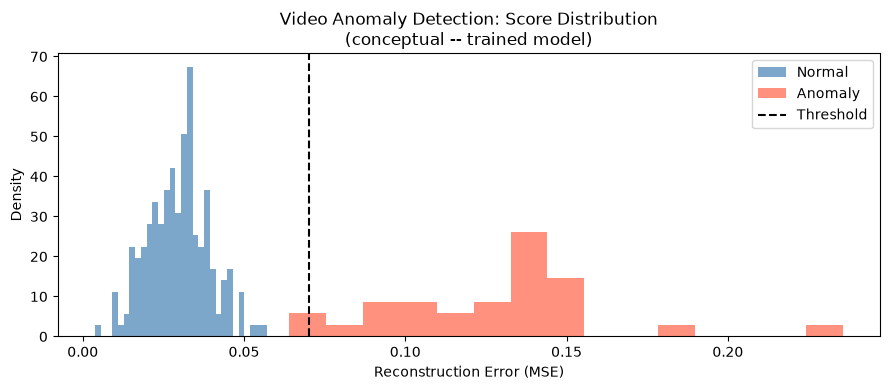

In [8]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Action Recognition with HuggingFace Video Models
# ============================================================

action_recognition_code = '''
from transformers import (
    VideoMAEImageProcessor, VideoMAEForVideoClassification,
    TimesformerConfig, TimesformerForVideoClassification,
    AutoImageProcessor
)
import torch, numpy as np

# ------ VideoMAE ------
processor = VideoMAEImageProcessor.from_pretrained("MCG-NJU/videomae-base-finetuned-kinetics")
model     = VideoMAEForVideoClassification.from_pretrained("MCG-NJU/videomae-base-finetuned-kinetics")

# 16 frames at 224x224
frames = [np.random.randint(0, 255, (224, 224, 3), dtype=np.uint8) for _ in range(16)]
inputs = processor(frames, return_tensors="pt")

with torch.no_grad():
    logits = model(**inputs).logits
top1_label = model.config.id2label[logits.argmax(-1).item()]
print(f"VideoMAE prediction: {top1_label}")

# ------ TimeSformer ------
processor2 = AutoImageProcessor.from_pretrained("facebook/timesformer-base-finetuned-k400")
model2 = TimesformerForVideoClassification.from_pretrained("facebook/timesformer-base-finetuned-k400")

# 8 frames for TimeSformer
frames8 = [np.random.randint(0, 255, (224, 224, 3), dtype=np.uint8) for _ in range(8)]
inputs2 = processor2(frames8, return_tensors="pt")

with torch.no_grad():
    logits2 = model2(**inputs2).logits
top1 = model2.config.id2label[logits2.argmax(-1).item()]
print(f"TimeSformer prediction: {top1}")
'''
print("Action Recognition Code:")
print(action_recognition_code)

# ============================================================
# Video Anomaly Detection, Reconstruction-Based (Sketch)
# ============================================================

class ConvAE(nn.Module):
    """Simple Conv Autoencoder for frame-level anomaly detection."""
    def __init__(self, in_ch=3, latent_dim=64):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(in_ch, 32, 4, 2, 1), nn.ReLU(),   # 112
            nn.Conv2d(32, 64, 4, 2, 1),    nn.ReLU(),   # 56
            nn.Conv2d(64, 128, 4, 2, 1),   nn.ReLU(),   # 28
            nn.Conv2d(128, latent_dim, 4, 2, 1), nn.ReLU()  # 14
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, 128, 4, 2, 1), nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, 2, 1),  nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, 2, 1),   nn.ReLU(),
            nn.ConvTranspose2d(32, in_ch, 4, 2, 1), nn.Sigmoid()
        )
    
    def forward(self, x):
        z     = self.encoder(x)
        recon = self.decoder(z)
        return recon
    
    def anomaly_score(self, x):
        """Reconstruction error as anomaly score (per frame)."""
        with torch.no_grad():
            recon = self.forward(x)
            score = ((x - recon)**2).mean(dim=(1, 2, 3))  # Mean per sample
        return score


ae = ConvAE(in_ch=3, latent_dim=64)
x_norm = torch.rand(4, 3, 224, 224)             # "Normal" frames
x_anom = torch.rand(4, 3, 224, 224) * 2 - 0.5  # "Anomalous" (out of [0,1] range)
x_anom = x_anom.clamp(0, 1)

recon_norm  = ae(x_norm)
scores_norm = ae.anomaly_score(x_norm)
scores_anom = ae.anomaly_score(x_anom)

print(f"\nConv Autoencoder:")
print(f"  Input: {x_norm.shape}  Reconstruction: {recon_norm.shape}")
print(f"  Normal frame scores:    {scores_norm.numpy().round(4)}")
print(f"  Anomalous frame scores: {scores_anom.numpy().round(4)}")
print(f"  (untrained model, scores not meaningful yet)")

params = sum(p.numel() for p in ae.parameters())
print(f"  Parameters: {params/1e3:.1f}K")

# Visualize anomaly score distribution concept
np.random.seed(42)
normal_scores  = np.random.normal(0.03, 0.01, 200)
anomaly_scores = np.random.normal(0.12, 0.03, 30)

plt.figure(figsize=(9, 4))
plt.hist(normal_scores,  bins=30, alpha=0.7, color='steelblue', label='Normal',  density=True)
plt.hist(anomaly_scores, bins=15, alpha=0.7, color='tomato',    label='Anomaly', density=True)
plt.axvline(0.07, color='k', linestyle='--', label='Threshold')
plt.xlabel('Reconstruction Error (MSE)')
plt.ylabel('Density')
plt.title('Video Anomaly Detection: Score Distribution\n(conceptual, trained model)')
plt.legend()
plt.tight_layout()
plt.show()

## Additional Learning Resources

### Foundational Papers

**3D CNNs & Architecture**
- [C3D: Learning Spatiotemporal Features with 3D CNNs](https://arxiv.org/abs/1412.0767) Tran et al. 2014
- [I3D: Quo Vadis, Action Recognition? A New Model and the Kinetics Dataset](https://arxiv.org/abs/1705.07750) Carreira & Zisserman 2017
- [R(2+1)D: A Closer Look at Spatiotemporal Convolutions](https://arxiv.org/abs/1711.11248) Tran et al. 2018
- [SlowFast Networks for Video Recognition](https://arxiv.org/abs/1812.03982) Feichtenbofer et al. 2019
- [X3D: Expanding Architectures for Efficient Video Recognition](https://arxiv.org/abs/2004.04730) Feichtenbofer 2020

**Temporal Modeling**
- [TSN: Temporal Segment Networks](https://arxiv.org/abs/1608.00859) Wang et al. 2016
- [TSM: Temporal Shift Module for Efficient Video Understanding](https://arxiv.org/abs/1811.08383) Lin et al. 2019
- [TDN: Temporal Difference Networks for Efficient Action Recognition](https://arxiv.org/abs/2012.10071) Wang et al. 2021
- [MViTv2: Improved Multiscale Vision Transformers](https://arxiv.org/abs/2112.01526) Li et al. 2022

**Video Transformers**
- [TimeSformer: Is Space-Time Attention All You Need?](https://arxiv.org/abs/2102.05095) Bertasius et al. 2021
- [ViViT: A Video Vision Transformer](https://arxiv.org/abs/2103.15691) Arnab et al. 2021
- [Video Swin Transformer](https://arxiv.org/abs/2106.13230) Liu et al. 2022
- [VideoMAE: Masked Autoencoders are Data-Efficient Learners for Self-Supervised Video Pre-Training](https://arxiv.org/abs/2203.12602) Tong et al. 2022
- [VideoMAE V2: Scaling Video Masked Autoencoders with Dual Masking](https://arxiv.org/abs/2303.16727) Wang et al. 2023

**Temporal Action Detection**
- [BSN: Boundary Sensitive Network for Temporal Action Proposals](https://arxiv.org/abs/1806.02964) Lin et al. 2018
- [BMN: Boundary-Matching Network for Temporal Action Proposal Generation](https://arxiv.org/abs/1907.09702) Lin et al. 2019
- [ActionFormer: Localizing Moments of Actions with Transformers](https://arxiv.org/abs/2202.07925) Zhang et al. 2022

**Object Tracking**
- [SORT: Simple Online and Realtime Tracking](https://arxiv.org/abs/1602.00763) Bewley et al. 2016
- [DeepSORT: Simple Online and Realtime Tracking with a Deep Association Metric](https://arxiv.org/abs/1703.07402) Wojke et al. 2017
- [ByteTrack: Multi-Object Tracking by Associating Every Detection Box](https://arxiv.org/abs/2110.06864) Zhang et al. 2022
- [OC-SORT: Observation-Centric SORT](https://arxiv.org/abs/2203.14360) Cao et al. 2022
- [BoT-SORT: Robust Associations Multi-Pedestrian Tracking](https://arxiv.org/abs/2206.14651) Aharon et al. 2022
- [CoTracker: It is Better to Track Together](https://arxiv.org/abs/2307.07635) Karaev et al. 2023

**Video Object Segmentation**
- [OSVOS: One-Shot Video Object Segmentation](https://arxiv.org/abs/1611.05198) Caelles et al. 2017
- [STCN: Rethinking Space-Time Networks with Improved Memory Coverage for Efficient Video Segmentation](https://arxiv.org/abs/2106.05210) Cheng et al. 2021
- [XMem: Long-Term Video Object Segmentation with an Atkinson-Shiffrin Memory Model](https://arxiv.org/abs/2207.07115) Cheng & Schwing 2022
- [SAM 2: Segment Anything in Images and Videos](https://arxiv.org/abs/2408.00714) Ravi et al. 2024

**Video Generation**
- [Make-A-Video: Text-to-Video Generation without Text-Video Data](https://arxiv.org/abs/2209.14792) Singer et al. 2022
- [Sora: Creating video from text](https://openai.com/sora) OpenAI 2024
- [VideoPoet: A Large Language Model for Zero-Shot Video Generation](https://arxiv.org/abs/2312.14125) Kondratyuk et al. 2024
- [CogVideoX: Text-to-Video Diffusion Models with An Expert Transformer](https://arxiv.org/abs/2408.06072) Yang et al. 2024
- [Open-Sora: Democratizing Efficient Video Production for All](https://arxiv.org/abs/2412.00131)

**Video LLMs**
- [Video-LLaMA: An Instruction-tuned Audio-Visual Language Model for Video Understanding](https://arxiv.org/abs/2306.02858) Zhang et al. 2023
- [VideoChat: Chat-Centric Video Understanding](https://arxiv.org/abs/2305.06355) Li et al. 2023
- [LLaVA-NeXT-Video](https://huggingface.co/lmms-lab/LLaVA-NeXT-Video-7B)
- [PLLaVA: Parameter-free LLaVA Extension from Images to Videos](https://arxiv.org/abs/2404.16994) Xu et al. 2024
- [InternVL2: Stronger and More Versatile](https://arxiv.org/abs/2412.05271) Chen et al. 2024
- [Qwen2-VL: Enhancing Vision-Language Model's Perception of the World at Any Resolution](https://arxiv.org/abs/2409.12191) Wang et al. 2024

---

### GitHub Repositories

| Repository | Description |
|------------|-------------|
| [facebookresearch/pytorchvideo](https://github.com/facebookresearch/pytorchvideo) | SlowFast, X3D, MViT implementations |
| [open-mmlab/mmaction2](https://github.com/open-mmlab/mmaction2) | Comprehensive action recognition toolbox |
| [MCG-NJU/VideoMAE](https://github.com/MCG-NJU/VideoMAE) | VideoMAE official code |
| [SwinTransformer/Video-Swin-Transformer](https://github.com/SwinTransformer/Video-Swin-Transformer) | Video Swin official |
| [ifzhang/ByteTrack](https://github.com/ifzhang/ByteTrack) | ByteTrack official |
| [mikel-brostrom/yolo_tracking](https://github.com/mikel-brostrom/yolo_tracking) | StrongSORT, BoT-SORT, ByteTrack unified |
| [facebookresearch/sam2](https://github.com/facebookresearch/sam2) | SAM 2 official |
| [hpcaitech/Open-Sora](https://github.com/hpcaitech/Open-Sora) | Open-source Sora |
| [DAMO-NLP-SG/Video-LLaMA](https://github.com/DAMO-NLP-SG/Video-LLaMA) | Video-LLaMA |
| [OpenGVLab/InternVideo](https://github.com/OpenGVLab/InternVideo) | InternVideo series |